# H-alpha Map Predictions — Epoch 116 on ALL Eligible Objects

Run on all ~520 DESI-MaNGA cross-matched objects. Sorted by cosine similarity for visual inspection.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import zarr
import matplotlib.pyplot as plt
import matplotlib as mpl
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from torch.utils.data import DataLoader

repo_root = Path('/pscratch/sd/p/pzehao/MultiModal')
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from models.MAESimple import MaskedAutoencoderViT
from utils.DataProcessing import MultimodalDataset
from utils.AstroImageFunctions import make_rgb

HA_REST = 6564.61
PIX_SCALE = 0.262
BATCH_SIZE = 1024

DESI_ZARR = Path('/pscratch/sd/p/pzehao/iron/desi_maglim_19_5.zarr')
DESI_PARQUET = Path('/pscratch/sd/p/pzehao/iron/desi_zcat_maglim_19_5.parquet')
MATCHES_CSV = Path('/pscratch/sd/p/pzehao/desi_manga_matches.csv')
DRPALL = Path('/pscratch/sd/p/pzehao/MyQuota/drpall-v3_1_1.fits')
MAPS_DIR = Path('/pscratch/sd/p/pzehao/MyQuota/manga_maps')
MAP_DAPTYPE = 'HYB10-MILESHC-MASTARHC2'
CKPT = Path('/pscratch/sd/p/pzehao/DESIMAE/ProductionCheckpointsSimple/epoch=116-val_loss=-1.5598.ckpt')

# Reproduce the same test set as two_ckpts_vs_baseline (seed_test=0, n_test=50)
SEED_TEST = 0
N_TEST = 50

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/_distutils_hack/__init__.py:15: UserWarning: Distutils was imported before Setuptools, but importing Setuptools also replaces the `distutils` module in `sys.modules`. This may lead to undesirable behaviors or errors. To avoid these issues, avoid using distutils directly, ensure that setuptools is installed in the traditional way (e.g. not an editable install), and/or make sure that setuptools is always imported before distutils.
  warnings.warn(
/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/_distutils_hack/__init__.py:30: UserWarning: Setuptools is replacing distutils. Support for replacing an already imported distutils is deprecated. In the future, this condition will fail. Register concerns at https://github.com/pypa/setuptools/issues/new?template=distutils-deprecation.yml
  warnings.warn(


/global/cfs/cdirs/desi/users/pzehao/envs/peng/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
def robust_normalize(x):
    x = np.asarray(x, dtype=np.float64)
    out = np.full_like(x, np.nan)
    m = np.isfinite(x)
    if m.sum() < 10:
        return out
    vals = x[m]
    med = np.nanmedian(vals)
    q25, q75 = np.nanpercentile(vals, [25, 75])
    iqr = q75 - q25
    scale = iqr if np.isfinite(iqr) and iqr > 0 else np.nanstd(vals)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    out[m] = (vals - med) / scale
    return out

def cosine_norm(pred_map, truth_map):
    m = np.isfinite(pred_map) & np.isfinite(truth_map)
    n = int(m.sum())
    if n < 10:
        return np.nan
    p = robust_normalize(pred_map[m]).ravel()
    t = robust_normalize(truth_map[m]).ravel()
    valid = np.isfinite(p) & np.isfinite(t)
    p, t = p[valid], t[valid]
    denom = np.linalg.norm(p) * np.linalg.norm(t)
    if denom <= 0:
        return np.nan
    return float(np.dot(p, t) / denom)

def extract_halpha_fast_batch(spectra, wave_obs, z_obj, left_patches, patch_size):
    arr = np.asarray(spectra, dtype=np.float64)
    L = len(wave_obs)
    if arr.shape[1] != L:
        off = int(left_patches) * int(patch_size)
        arr = arr[:, off:off + L]
    lam0 = HA_REST * (1.0 + z_obj)
    win_half = 45.0 * (1.0 + z_obj)
    m_win = (wave_obs >= lam0 - win_half) & (wave_obs <= lam0 + win_half)
    m_side = m_win & ((wave_obs < lam0 - 12.0) | (wave_obs > lam0 + 12.0))
    if int(np.sum(m_win)) < 5:
        return np.full(arr.shape[0], np.nan)
    w_line = wave_obs[m_win]
    f_line = arr[:, m_win]
    cont = np.nanmedian(arr[:, m_side], axis=1) if int(np.sum(m_side)) >= 5 else np.nanmedian(f_line, axis=1)
    line = np.clip(f_line - cont[:, None], 0.0, None)
    return np.trapz(line, w_line, axis=1).astype(np.float64)

def _ch(header, token):
    token = token.lower()
    for k, v in header.items():
        if isinstance(k, str) and k.startswith('C') and isinstance(v, str) and token in v.lower():
            return int(k[1:]) - 1
    raise KeyError(token)

def _masked(h, ext, idx=None):
    d = np.asarray(h[ext].data if idx is None else h[ext].data[idx], dtype=np.float32)
    bad = np.zeros_like(d, dtype=bool)
    me = f'{ext}_MASK'
    ie = f'{ext}_IVAR'
    if me in h:
        m = np.asarray(h[me].data if idx is None else h[me].data[idx])
        bad |= m != 0
    if ie in h:
        iv = np.asarray(h[ie].data if idx is None else h[ie].data[idx], dtype=np.float32)
        bad |= (~np.isfinite(iv)) | (iv <= 0)
    d[bad] = np.nan
    return d

print('Helper functions defined.')

Helper functions defined.


In [3]:
# Load tables, build test set, load model
desi_tab = pd.read_parquet(DESI_PARQUET,
    columns=['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'MEAN_FIBER_RA', 'MEAN_FIBER_DEC', 'Z']).copy()
desi_tab['TARGETID'] = desi_tab['TARGETID'].astype(np.int64)

matches_df = pd.read_csv(MATCHES_CSV)
desi_targetids = set(desi_tab['TARGETID'].values)
elig = matches_df[matches_df['TARGETID'].isin(desi_targetids)].reset_index(drop=True)
uniq = pd.unique(elig['TARGETID'].astype(np.int64))

# Same test split as two_ckpts_vs_baseline
rng = np.random.default_rng(SEED_TEST)
test_ids = list(rng.choice(uniq, size=min(N_TEST, len(uniq)), replace=False))
test_ids = [int(t) for t in test_ids]

# Build plateifu lookup from matches CSV
tid_to_pifu = dict(zip(elig['TARGETID'].astype(np.int64), elig['plateifu'].astype(str)))

tbl = Table.read(DRPALL, hdu=1)
one_d = [c for c in tbl.colnames if len(tbl[c].shape) <= 1]
manga_df = tbl[one_d].to_pandas()[['plateifu', 'objra', 'objdec']].copy()
manga_df['plateifu'] = manga_df['plateifu'].astype(str)

zstore = zarr.open(str(DESI_ZARR), mode='r')
wave_obs = np.asarray(zstore['WAVE'][:], dtype=np.float64)

prob = 0.7 / 15
model = MaskedAutoencoderViT(
    spec_dim=7781, max_epochs=600, warmup_epoch=5, mask_ratio=0.75,
    embed_dim=256, merged_depth=4, merged_num_heads=8,
    s_depth=4, e_depth=4, s_num_heads=8, e_num_heads=8,
    decoder_embed_dim=512, decoder_depth=8, decoder_num_heads=16,
    decoder_MLP_coefficient=1,
    patch_scheme={
        'patch_sizes': [1,1,2,4,8,16,32,64,128,64,32,16,8,4,2,1],
        'mask_ratios': [1,0.9,0.8,0.75,0.7,0.65,0.6,0.55,0.5,0.45,0.4,0.35,0.3,0.2,0.1,0.0],
        'probs': [0.3] + [prob]*15,
    })

chk = torch.load(CKPT, map_location='cpu')
model.load_state_dict(chk['state_dict'], strict=False)
model.mask_ratio = 1.0
model.mask_ratio_img = 0.0
model.eval()
model = model.to(device)
torch.set_grad_enabled(False)

print(f'Model loaded from {CKPT.name}')
print(f'{len(uniq)} eligible objects, {len(test_ids)} in test set')

/tmp/ipykernel_838348/191080844.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  chk = torch.load(CKPT, map_location='cpu')


Model loaded from epoch=116-val_loss=-1.5598.ckpt
520 eligible objects, 50 in test set


In [4]:
def process_object(targetid):
    """Generate H-alpha prediction map for one object by TARGETID."""
    plateifu = tid_to_pifu.get(targetid)
    if plateifu is None:
        return None

    hit = desi_tab.loc[desi_tab['TARGETID'] == targetid]
    if hit.empty:
        return None
    desi_index = int(hit.index[0])
    desi_row = desi_tab.iloc[desi_index]
    target_ra = float(desi_row['TARGET_RA'])
    target_dec = float(desi_row['TARGET_DEC'])
    z_obj = float(desi_row['Z'])

    plate, ifu = plateifu.split('-')
    maps_path = MAPS_DIR / f'manga-{plateifu}-MAPS-{MAP_DAPTYPE}.fits.gz'
    if not maps_path.exists():
        from urllib.request import urlretrieve
        url = (f'https://data.sdss.org/sas/dr17/manga/spectro/analysis/v3_1_1/3.1.0/'
               f'{MAP_DAPTYPE}/{plate}/{ifu}/manga-{plateifu}-MAPS-{MAP_DAPTYPE}.fits.gz')
        MAPS_DIR.mkdir(parents=True, exist_ok=True)
        urlretrieve(url, maps_path)

    with fits.open(maps_path) as h:
        i_ha = _ch(h['EMLINE_GFLUX'].header, 'Ha-6564')
        ha_truth = _masked(h, 'EMLINE_GFLUX', i_ha).astype(np.float64)
        wcs_map = WCS(h['SPX_MFLUX'].header).celestial

    ny, nx = ha_truth.shape
    iy, ix = np.indices((ny, nx))
    ra_grid, dec_grid = wcs_map.pixel_to_world_values(ix.ravel(), iy.ravel())

    # Same convention as eval_two_ckpts_vs_baseline and eval_halpha_checkpoint_sweep
    x_off = (-1.0 * (ra_grid - target_ra) * np.cos(np.deg2rad(target_dec)) * 3600.0 / PIX_SCALE).reshape(ny, nx)
    y_off = (-1.0 * (dec_grid - target_dec) * 3600.0 / PIX_SCALE).reshape(ny, nx)

    inside_desi = (np.abs(x_off) <= 63) & (np.abs(y_off) <= 63)
    valid = np.isfinite(ha_truth) & inside_desi
    if valid.sum() < 20:
        return None

    coords = np.column_stack([x_off[valid], y_off[valid]]).astype(np.float32)
    yx_pairs = np.column_stack(np.where(valid)).astype(np.int32)

    ds = MultimodalDataset(str(DESI_ZARR), start=desi_index, end=desi_index+1, augment=False, max_shift=0)
    batch = next(iter(DataLoader(ds, batch_size=1, shuffle=False)))
    x0, spec0, weig0, error0, img0, img_w0, img_e0, z0, xy0 = batch

    img_6ch = img0[0].detach().cpu().numpy()
    desi_rgb = make_rgb(img_6ch[[0, 1, 3]], 'ls_grz')

    spec0, weig0, error0 = spec0.to(device), weig0.to(device), error0.to(device)
    img0, img_w0, img_e0 = img0.to(device), img_w0.to(device), img_e0.to(device)
    z0 = z0.to(device)

    out_map = np.full_like(ha_truth, np.nan, dtype=np.float64)
    n = coords.shape[0]
    with torch.inference_mode():
        for start in range(0, n, BATCH_SIZE):
            end = min(start + BATCH_SIZE, n)
            bsz = end - start
            xy_chunk = torch.as_tensor(coords[start:end], dtype=xy0.dtype, device=device)
            _, _, _, spec_pred, _, _, _, _ = model.forward(
                spec0.expand(bsz, -1), weig0.expand(bsz, -1), error0.expand(bsz, -1),
                img0.expand(bsz, -1, -1, -1), img_w0.expand(bsz, -1, -1, -1), img_e0.expand(bsz, -1, -1, -1),
                z0.expand(bsz), xy_chunk)
            pred_np = spec_pred.detach().cpu().numpy()
            hvals = extract_halpha_fast_batch(pred_np, wave_obs, z_obj, model.left_patches, model.patch_size)
            loc = yx_pairs[start:end]
            out_map[loc[:, 0], loc[:, 1]] = hvals

    cos = cosine_norm(out_map, ha_truth)
    return {
        'targetid': targetid, 'plateifu': plateifu,
        'z': z_obj, 'truth': ha_truth, 'pred': out_map, 'cosine': cos,
        'x_off': x_off, 'y_off': y_off, 'desi_rgb': desi_rgb,
    }

print('process_object() defined.')

process_object() defined.


In [5]:
# Only run on objects already known to have cos >= 0.7 from the baseline experiment
import time
prev_metrics = pd.read_csv('/pscratch/sd/p/pzehao/MultiModal/notebooks/two_ckpts_vs_baseline/perobj_metrics.csv')
prev_best = prev_metrics[prev_metrics['method'] == 'ckpt_epoch_074']
good_tids = prev_best[prev_best['cosine_norm'] >= 0.7]['targetid'].astype(int).tolist()
print(f'{len(good_tids)} objects with cos >= 0.7 from baseline experiment')

results = []
t0 = time.time()
for i, tid in enumerate(good_tids, 1):
    print(f'[{i}/{len(good_tids)}] tid={tid}...', end=' ', flush=True)
    try:
        res = process_object(tid)
        if res is not None:
            results.append(res)
            print(f'pifu={res["plateifu"]} cos={res["cosine"]:.4f}')
        else:
            print('skipped')
    except Exception as e:
        print(f'FAILED: {e}')

cosines = [r['cosine'] for r in results if np.isfinite(r['cosine'])]
print(f'\nCompleted {len(results)}/{len(good_tids)} in {time.time()-t0:.0f}s')
print(f'Cosine similarity: median={np.median(cosines):.4f}, mean={np.mean(cosines):.4f}')

24 objects with cos >= 0.7 from baseline experiment
[1/24] tid=39628518102927704... 

pifu=11948-3704 cos=0.9690
[2/24] tid=39633188032611680... 

pifu=8488-3702 cos=0.7399
[3/24] tid=39628527561085432... 

pifu=12484-9101 cos=0.7070
[4/24] tid=39633267195904912... 

pifu=8997-3702 cos=0.9576
[5/24] tid=39632936319847968... 

...

pifu=12495-6103 cos=0.9576
[21/24] tid=39628426776153064... 

pifu=8148-6101 cos=0.7280
[22/24] tid=39627872985417776... 

pifu=11835-12703 cos=0.8931
[23/24] tid=39628005387011464... 

pifu=11960-12703 cos=0.8667
[24/24] tid=39628444518058848... 

pifu=9042-9101 cos=0.8194

Completed 24/24 in 236s
Cosine similarity: median=0.8583, mean=0.8192


In [6]:
# Sort by cosine similarity (best to worst)
show = sorted(results, key=lambda r: r['cosine'], reverse=True)
print(f'{len(show)} objects to visualize')

24 objects to visualize


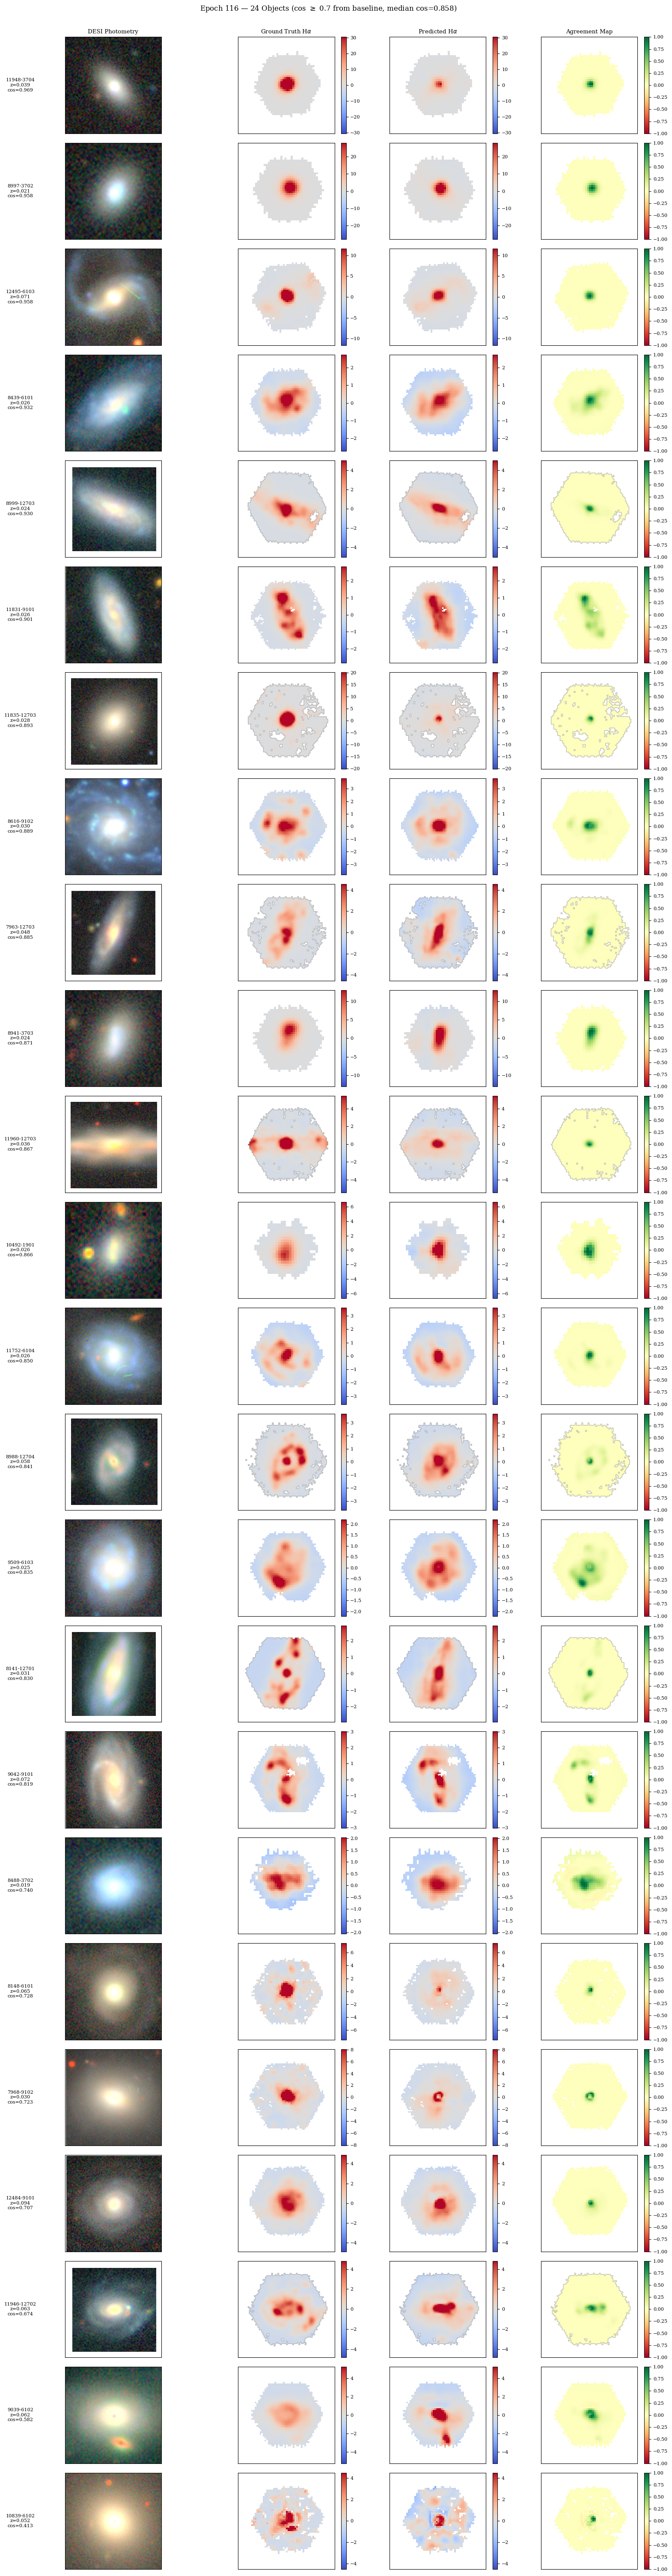

Saved halpha_epoch116_testset.png


In [7]:
# Visualize all objects with cos >= 0.7
mpl.rcParams.update({'font.family': 'serif', 'font.size': 8})

n_obj = len(show)
fig, axes = plt.subplots(n_obj, 4, figsize=(16, 2.5 * n_obj))
if n_obj == 1:
    axes = axes[np.newaxis, :]

for i, res in enumerate(show):
    truth = res['truth']
    pred = res['pred']
    x_off = res['x_off']
    y_off = res['y_off']
    cos_val = res['cosine']
    desi_rgb = res['desi_rgb']

    truth_n = robust_normalize(truth)
    pred_n = robust_normalize(pred)

    both_valid = np.isfinite(truth_n) & np.isfinite(pred_n)
    vals = np.concatenate([truth_n[both_valid], pred_n[both_valid]])
    v = float(np.nanpercentile(np.abs(vals), 98)) if len(vals) > 0 else 1.0

    manga_ext = [np.nanmin(x_off), np.nanmax(x_off), np.nanmin(y_off), np.nanmax(y_off)]
    desi_ext = [-64, 64, -64, 64]
    xlim = (manga_ext[0] - 4, manga_ext[1] + 4)
    ylim = (manga_ext[2] - 4, manga_ext[3] + 4)

    axes[i, 0].imshow(desi_rgb, origin='lower', extent=desi_ext)
    if i == 0:
        axes[i, 0].set_title('DESI Photometry')

    im1 = axes[i, 1].imshow(truth_n, origin='lower', cmap='coolwarm', vmin=-v, vmax=v, extent=manga_ext)
    if i == 0:
        axes[i, 1].set_title('Ground Truth H$\\alpha$')
    plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

    im2 = axes[i, 2].imshow(pred_n, origin='lower', cmap='coolwarm', vmin=-v, vmax=v, extent=manga_ext)
    if i == 0:
        axes[i, 2].set_title('Predicted H$\\alpha$')
    plt.colorbar(im2, ax=axes[i, 2], fraction=0.046, pad=0.04)

    sim_map = np.full_like(truth_n, np.nan)
    sim_map[both_valid] = truth_n[both_valid] * pred_n[both_valid]
    mx = np.nanmax(np.abs(sim_map[both_valid])) if both_valid.any() else 1.0
    sim_map[both_valid] = sim_map[both_valid] / (mx + 1e-10)
    im3 = axes[i, 3].imshow(sim_map, origin='lower', cmap='RdYlGn', vmin=-1, vmax=1, extent=manga_ext)
    if i == 0:
        axes[i, 3].set_title('Agreement Map')
    plt.colorbar(im3, ax=axes[i, 3], fraction=0.046, pad=0.04)

    label = f'{res["plateifu"]}\nz={res["z"]:.3f}\ncos={cos_val:.3f}'
    axes[i, 0].set_ylabel(label, fontsize=8, rotation=0, labelpad=75, va='center')

    for ax in axes[i]:
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])

fig.suptitle(f'Epoch 116 — {n_obj} Objects (cos $\\geq$ 0.7 from baseline, '
             f'median cos={np.median(cosines):.3f})',
             fontsize=12, y=1.002)
fig.tight_layout()
plt.savefig('halpha_epoch116_testset.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved halpha_epoch116_testset.png')